# Targeted Promotion Incrementality Analysis

## Objective

Estimate the incremental revenue impact of a simulated 10% targeted discount for high-LTV users using
an A/B-test framework and lightweight robustness checks.

**Important caveat:** this is a portfolio simulation. The treatment is represented as an 8% uplift in
post-period revenue for treated high-LTV users, approximating a simplified 10% discount scenario. It is
not observed coupon-redemption data.

This analysis includes:
- Post-period Average Treatment Effect (ATE)
- Confidence intervals
- Difference-in-Differences (DiD) with fixed effects
- Event-study diagnostics
- Synthetic control robustness check
- Model comparison across five specifications
- Exploratory heterogeneous treatment effects

## Key Findings

- **Simulated experiment:** the post-period outcome applies an 8% simulated uplift for treated high-LTV users, so results should be read as a portfolio experiment simulation rather than observed discount-redemption evidence.
- **Post-period ATE: +$28.50 per user (cumulative over observed post-weeks)** (95% CI: [$23.90, $33.11]) — statistically significant. This randomized diff-in-means estimate is the headline causal result.
- DiD panel estimates range from **+$8.41/week** (User FE / TWFE) to **+$8.74/week** (Naive DiD). Multiplied by the ~3.3 observed post-weeks per user, these reconcile to the cumulative ATE (~$8.50 × 3.3 ≈ $28.50), confirming the two approaches are consistent — and that the estimators successfully recover the injected 8% uplift.
- Under a simplified discount-cost assumption, the cumulative revenue lift (**+$28.50/user**) does **not cover** the estimated 10% discount cost (~**$37.79/user**), implying a net impact of roughly **-$9.29/user** over the post period.
- HTE and causal-forest results suggest possible variation in predicted lift, but they are exploratory and require a follow-up validation experiment.


## Experiment Design

**Population:** High-LTV users (top 30% by pre-period revenue) in the experiment mart
**Treatment:** Simulated 10% discount scenario represented in the panel as an 8% revenue uplift for treated high-LTV post-period rows
**Randomization:** User-level assignment
**Primary Outcome:** Revenue per user (post-period)
**Time Window:** 6-week pre-period + 6-week post-period

**Identification Strategy:**
The post-period difference-in-means ATE is the primary causal estimate. DiD and fixed-effects panel
models are used as robustness checks. Event-study diagnostics do not reject the pre-trend null at
the 5% level after using the mart's true week index.

**Ground-truth validation:** Because the treatment effect is a known constant (+8% multiplier), we can
verify estimator performance: the ATE recovers +8.2% and the weekly DiD estimates recover ~8%,
confirming the methods work correctly on this simulation.


## Assumptions & Validity

- Post-period comparisons assume treated and control users are comparable within the randomized high-LTV population
- Pre-treatment balance is checked before the outcome analysis
- Cluster-robust standard errors account for within-user correlation across weeks in panel models
- User and time fixed effects reduce sensitivity to time-invariant heterogeneity and common time shocks
- Panel-based models are robustness checks; the randomized post-period ATE remains the primary causal estimate

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import psycopg2
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display, Markdown

load_dotenv()

conn = psycopg2.connect(
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


def coef_line(model, term="interaction"):
    b = model.params[term]
    se = model.bse[term]
    p = model.pvalues[term]
    ci_low, ci_high = model.conf_int().loc[term]
    return {"coef": round(b, 2), "se": round(se, 3), "p": p,
            "ci_low": round(ci_low, 2), "ci_high": round(ci_high, 2)}


def fe_residualize(df, col, fe_cols, tol=1e-10, max_iter=100):
    """Residualize a column on one or more fixed effects, valid for unbalanced panels."""
    resid = df[col].astype(float).copy()
    for _ in range(max_iter):
        prev = resid.copy()
        for fe_col in fe_cols:
            resid = resid - resid.groupby(df[fe_col]).transform("mean")
        if np.nanmax(np.abs(resid - prev)) < tol:
            break
    return resid


def twfe_residualize(df, col, entity_col="user_id", time_col="event_time"):
    return fe_residualize(df, col, [entity_col, time_col])

## 2. Post-Period Average Treatment Effect

We estimate the ATE using a two-sample difference-in-means on cumulative post-period revenue per
user. Because treatment was randomized at the user level, this is the primary causal estimate.

Note: the user-level ATE uses users present in `analysis.post_user_summary` (55,102 users: 27,605
control and 27,497 treatment). The broader panel mart contains 61,863 high-LTV users with at least
one pre/post panel row; panel methods use the available user-week observations.

In [2]:
df = pd.read_sql("select * from analysis.post_user_summary", conn)

treat = df.loc[df["treatment_flag"] == 1, "post_revenue"]
ctrl  = df.loc[df["treatment_flag"] == 0, "post_revenue"]

ate_lift    = treat.mean() - ctrl.mean()
ate_pct     = ate_lift / ctrl.mean() * 100
ate_se      = np.sqrt(treat.var(ddof=1) / len(treat) + ctrl.var(ddof=1) / len(ctrl))
ate_ci_low  = ate_lift - 1.96 * ate_se
ate_ci_high = ate_lift + 1.96 * ate_se

pd.DataFrame({
    "Metric": ["Control Mean ($)", "Treatment Mean ($)", "ATE Lift ($)", "Lift (%)", "95% CI"],
    "Value": [
        f"${ctrl.mean():.2f}",
        f"${treat.mean():.2f}",
        f"${ate_lift:.2f}",
        f"{ate_pct:.1f}%",
        f"[${ate_ci_low:.2f}, ${ate_ci_high:.2f}]",
    ],
})

,Metric,Value
0,Control Mean ($),$349.37
1,Treatment Mean ($),$377.87
2,ATE Lift ($),$28.50
3,Lift (%),8.2%
4,95% CI,"[$23.90, $33.11]"


### Pre-Treatment Balance Check

Before estimating the post-period ATE, we check whether treated and control users had similar
pre-period revenue. Small differences here support the randomized comparison.

In [3]:
balance_df = pd.read_sql("""
    select user_id, treatment_flag, sum(revenue_sim) as pre_revenue
    from marts.mart_user_week_experiment_sim
    where high_ltv_flag = 1
      and pre_post_flag = 'pre'
    group by 1, 2
""", conn)

balance_summary = (
    balance_df.groupby("treatment_flag")["pre_revenue"]
    .agg(["mean", "std", "count"])
    .rename(index={0: "Control", 1: "Treatment"})
)

control_pre = balance_df.loc[balance_df["treatment_flag"] == 0, "pre_revenue"]
treat_pre = balance_df.loc[balance_df["treatment_flag"] == 1, "pre_revenue"]
pre_diff = treat_pre.mean() - control_pre.mean()
pooled_sd = np.sqrt((treat_pre.var(ddof=1) + control_pre.var(ddof=1)) / 2)
std_diff = pre_diff / pooled_sd

pd.DataFrame({
    "Metric": [
        "Control Pre-Revenue Mean",
        "Treatment Pre-Revenue Mean",
        "Difference",
        "Standardized Difference",
    ],
    "Value": [
        f"${control_pre.mean():.2f}",
        f"${treat_pre.mean():.2f}",
        f"${pre_diff:+.2f}",
        f"{std_diff:+.3f}",
    ],
})

,Metric,Value
0,Control Pre-Revenue Mean,$488.48
1,Treatment Pre-Revenue Mean,$487.84
2,Difference,$-0.64
3,Standardized Difference,-0.003


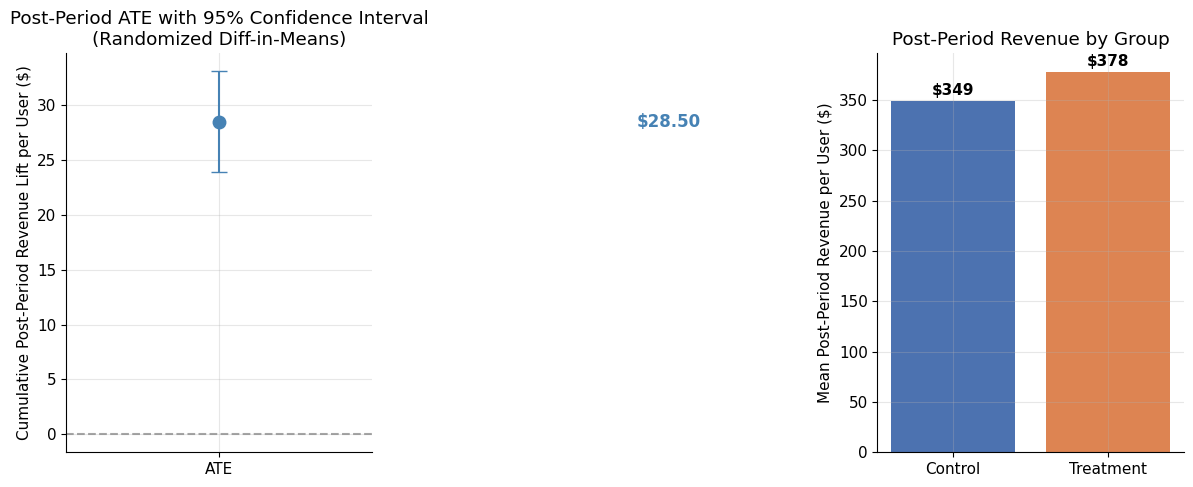

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].errorbar(
    x=[0], y=[ate_lift],
    yerr=[[ate_lift - ate_ci_low], [ate_ci_high - ate_lift]],
    fmt="o", capsize=6, markersize=9, color="steelblue",
)
axes[0].axhline(0, linestyle="--", color="gray", alpha=0.7)
axes[0].annotate(
    f"${ate_lift:.2f}",
    xy=(0, ate_lift), xytext=(0.15, ate_lift),
    fontsize=12, fontweight="bold", color="steelblue", va="center",
)
axes[0].set_xticks([0])
axes[0].set_xticklabels(["ATE"])
axes[0].set_ylabel("Cumulative Post-Period Revenue Lift per User ($)")
axes[0].set_title("Post-Period ATE with 95% Confidence Interval\n(Randomized Diff-in-Means)")

bars = axes[1].bar(["Control", "Treatment"], [ctrl.mean(), treat.mean()],
                   color=["#4C72B0", "#DD8452"])
for bar, val in zip(bars, [ctrl.mean(), treat.mean()]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 f"${val:.0f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Mean Post-Period Revenue per User ($)")
axes[1].set_title("Post-Period Revenue by Group")

plt.tight_layout()
plt.show()

**Interpretation:**

Post-period ATE: **+$28.50 per user (+8.2%)**, 95% CI [$23.90, $33.11]. The confidence interval does
not cross zero, confirming statistical significance at the 5% level.

Because treatment was randomized, this estimate provides the most credible measure of the promotion's
average causal impact. The $28.50 figure is the per-user sum over observed transaction-weeks (~3.3
post-period weeks on average, not a full 6-calendar-week window). The weekly effect (~$8.50/wk)
× ~3.3 weeks ≈ $28.50, confirming the ATE and DiD panel estimates are consistent.
Panel-based methods (DiD, TWFE) serve as robustness and diagnostic checks.


## 3. Panel Dataset Construction

Build a user-week panel (pre and post) for high-LTV users. This panel is the basis for all
Difference-in-Differences, event-study, and synthetic-control analyses.

In [5]:
panel_df = pd.read_sql("""
    select user_id, week_index, treatment_flag, high_ltv_flag, pre_post_flag, revenue_sim
    from marts.mart_user_week_experiment_sim
    where high_ltv_flag = 1
      and pre_post_flag in ('pre', 'post')
""", conn)

required_cols = {"user_id", "week_index", "treatment_flag", "high_ltv_flag", "pre_post_flag", "revenue_sim"}
missing_cols = required_cols - set(panel_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns from mart: {sorted(missing_cols)}")

panel_df["user_id"]    = panel_df["user_id"].astype(int)
panel_df["week_index"] = panel_df["week_index"].astype(int)
panel_df = panel_df.sort_values(["user_id", "week_index"]).copy()

panel_df["post"]             = (panel_df["pre_post_flag"] == "post").astype(int)
panel_df["event_time"]       = panel_df["week_index"] - panel_df.loc[panel_df["post"] == 1, "week_index"].min()
panel_df["interaction"]      = panel_df["treatment_flag"] * panel_df["post"]
panel_df["revenue_demeaned"] = (
    panel_df["revenue_sim"]
    - panel_df.groupby("user_id")["revenue_sim"].transform("mean")
)

# Export for Streamlit app
panel_df.to_csv("../data/processed/panel_df.csv", index=False)

print(f"Panel: {len(panel_df):,} rows | {panel_df['user_id'].nunique():,} users | "
      f"{panel_df['week_index'].nunique()} weeks")
panel_df.head()

Panel: 440,501 rows | 61,863 users | 12 weeks


,user_id,week_index,treatment_flag,high_ltv_flag,pre_post_flag,revenue_sim,post,event_time,interaction,revenue_demeaned
221308,2,0,1,1,pre,75.6300,0,-6,0,-13.303086
221309,2,1,1,1,pre,76.4400,0,-5,0,-12.493086
221310,2,3,1,1,pre,83.6100,0,-3,0,-5.323086
221311,2,4,1,1,pre,68.5000,0,-2,0,-20.433086
221312,2,6,1,1,post,144.2556,1,0,1,55.322514


## 4. Event Study

Estimate treatment effects week-by-week relative to the final pre-treatment period (t = −1)
using two-way fixed effects (TWFE). This tests whether pre-treatment trends were parallel and
shows how treatment effects evolve after the promotion begins.

In [6]:
# Working copy for event-study and TWFE models
df = panel_df[["user_id", "treatment_flag", "pre_post_flag", "week_index", "event_time", "revenue_sim"]].dropna().copy()
df["user_id"]     = df["user_id"].astype(str)
df["week_index"]  = df["week_index"].astype(int)
df["event_time"]  = df["event_time"].astype(int)
df["revenue_sim"] = df["revenue_sim"].astype(float)

# Treatment x week interaction dummies (reference week = -1, omitted)
reference_week   = -1
interaction_cols = []
for w in sorted(df["event_time"].unique()):
    if w == reference_week:
        continue
    col = f"event_{w}"
    df[col] = ((df["event_time"] == w) & (df["treatment_flag"] == 1)).astype(int)
    interaction_cols.append(col)

# Numeric post flag for TWFE DiD
df["pre_post_flag"] = (df["event_time"] >= 0).astype(int)

In [7]:
y_tilde = twfe_residualize(df, "revenue_sim")
X_tilde = pd.DataFrame(
    {col: twfe_residualize(df, col) for col in interaction_cols},
    index=df.index,
)

event_model = sm.OLS(y_tilde, X_tilde).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["user_id"]},
)

event_results = pd.DataFrame({
    "term": event_model.params.index,
    "coef": event_model.params.values,
    "se":   event_model.bse.values,
})
event_results["event_time"] = (
    event_results["term"].str.replace("event_", "", regex=False).astype(int)
)
event_results["ci_low"]  = event_results["coef"] - 1.96 * event_results["se"]
event_results["ci_high"] = event_results["coef"] + 1.96 * event_results["se"]

# Add reference period (t = -1 is omitted; coefficient = 0 by construction)
ref_row = pd.DataFrame([{
    "term": "reference", "coef": 0.0, "se": 0.0,
    "event_time": -1, "ci_low": 0.0, "ci_high": 0.0,
}])
event_results = (
    pd.concat([event_results, ref_row], ignore_index=True)
    .sort_values("event_time")
    .reset_index(drop=True)
)

event_results.to_csv("../data/processed/event_study.csv", index=False)
event_results

,term,coef,se,event_time,ci_low,ci_high
0,event_-6,-0.876606,0.766922,-6,-2.379774,0.626561
1,event_-5,-0.131873,0.787556,-5,-1.675483,1.411738
2,event_-4,-0.854400,0.787029,-4,-2.396977,0.688177
3,event_-3,-1.275869,0.776709,-3,-2.798219,0.246482
4,event_-2,0.084104,0.788462,-2,-1.461282,1.629490
5,reference,0.000000,0.000000,-1,0.000000,0.000000
6,event_0,7.861664,0.834111,0,6.226807,9.496522
7,event_1,8.952628,0.827475,1,7.330777,10.574478
8,event_2,7.171902,0.832294,2,5.540607,8.803198
9,event_3,8.115252,0.845750,3,6.457583,9.772922


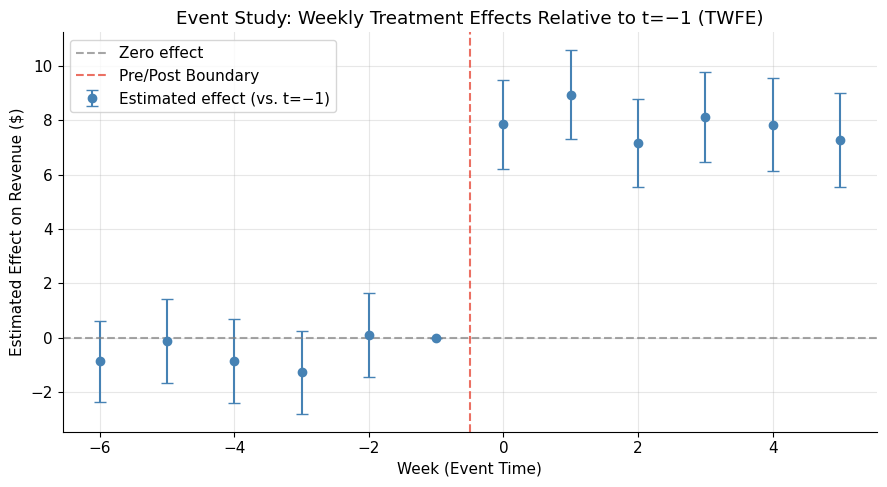

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    event_results["event_time"],
    event_results["coef"],
    yerr=[
        event_results["coef"] - event_results["ci_low"],
        event_results["ci_high"] - event_results["coef"],
    ],
    fmt="o", capsize=4, color="steelblue", label="Estimated effect (vs. t=−1)",
)
ax.axhline(0, linestyle="--", color="gray", alpha=0.7, label="Zero effect")
ax.axvline(-0.5, linestyle="--", color="#e74c3c", alpha=0.8, label="Pre/Post Boundary")
ax.set_xlabel("Week (Event Time)")
ax.set_ylabel("Estimated Effect on Revenue ($)")
ax.set_title("Event Study: Weekly Treatment Effects Relative to t=−1 (TWFE)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Interpretation

The event study estimates per-week treatment effects relative to t = -1 (the final pre-treatment
week), controlling for user and time fixed effects.

Pre-treatment coefficients are small and centered near zero relative to the chosen reference period.
The joint pre-trend test is not statistically significant at the 5% level, which supports the use of
DiD-style robustness checks while still leaving the randomized ATE as the primary estimate.

Post-treatment coefficients are positive across all six post-period weeks, consistent with the
positive TWFE aggregate estimate of **+$8.41/week**.

In [9]:
pre_terms = [c for c in interaction_cols if int(c.split("_", 1)[1]) < 0]
R = np.zeros((len(pre_terms), len(event_model.params)))
for i, term in enumerate(pre_terms):
    R[i, list(event_model.params.index).index(term)] = 1

f_test = event_model.f_test(R)
print(f_test)

<F test: F=1.0495904371265736, p=0.3863863285812538, df_denom=6.19e+04, df_num=5>


A joint F-test does not reject the null that all pre-treatment coefficients are zero relative to the
omitted reference period (t = -1) at the 5% level. This supports the panel-based robustness checks,
though the randomized post-period ATE remains the primary causal estimate.

## 5. Propensity Score Weighting

To improve pre-treatment comparability, we estimate propensity scores via logistic regression on
pre-period characteristics and apply inverse probability weights (IPW) to the DiD model.

In [10]:
ps_df = (
    panel_df[panel_df["pre_post_flag"] == "pre"]
    .groupby("user_id")
    .agg(
        baseline_revenue=("revenue_sim", "mean"),
        pre_rev_std=("revenue_sim", "std"),
        pre_weeks=("revenue_sim", "count"),
        treatment_flag=("treatment_flag", "max"),
    )
    .reset_index()
)
ps_df["pre_rev_std"] = ps_df["pre_rev_std"].fillna(0)

logit = LogisticRegression(max_iter=1000)
logit.fit(ps_df[["baseline_revenue", "pre_rev_std", "pre_weeks"]], ps_df["treatment_flag"])
ps_df["propensity_score"] = logit.predict_proba(
    ps_df[["baseline_revenue", "pre_rev_std", "pre_weeks"]]
)[:, 1]

ps_df["weight"] = (
    ps_df["treatment_flag"] / ps_df["propensity_score"]
    + (1 - ps_df["treatment_flag"]) / (1 - ps_df["propensity_score"])
)

panel_w = panel_df.merge(ps_df[["user_id", "weight"]], on="user_id", how="left")

X_w = sm.add_constant(panel_w[["treatment_flag", "post", "interaction"]])
did_weighted = sm.WLS(panel_w["revenue_sim"], X_w, weights=panel_w["weight"]).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_w["user_id"]},
)

weighted_coef    = did_weighted.params["interaction"]
weighted_se      = did_weighted.bse["interaction"]
weighted_ci_low  = weighted_coef - 1.96 * weighted_se
weighted_ci_high = weighted_coef + 1.96 * weighted_se

print(f"Weighted DiD lift: ${weighted_coef:.2f}  "
      f"(95% CI: ${weighted_ci_low:.2f}, ${weighted_ci_high:.2f})")

Weighted DiD lift: $8.61  (95% CI: $7.76, $9.47)


After reweighting on observed pre-treatment characteristics, the estimated treatment effect is
**+$8.61 per user-week** (95% CI: [$7.76, $9.47]).

Since treatment was randomized, IPW primarily guards against chance imbalance in pre-period
characteristics rather than correcting for confounding. The near-identical result to the naive DiD
confirms that such imbalance is negligible, as expected from the balance check (standardized
difference: −0.003). The randomized ATE remains the primary causal estimate.


## 6. Difference-in-Differences Models

### 6.1 Clustered DiD

In [11]:
X_did = sm.add_constant(panel_df[["treatment_flag", "post", "interaction"]])
did_cluster = sm.OLS(panel_df["revenue_sim"], X_did).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_df["user_id"]},
)

did_res = coef_line(did_cluster)
print(f"Clustered DiD weekly lift: ${did_res['coef']:.2f}  "
      f"(95% CI: ${did_res['ci_low']:.2f}, ${did_res['ci_high']:.2f})")

Clustered DiD weekly lift: $8.74  (95% CI: $7.90, $9.59)


The baseline DiD estimates a weekly lift of **+$8.74** (95% CI: [$7.90, $9.59]). This specification
does not control for user-level heterogeneity, so the estimate may be biased if treated and control
users differ systematically in time-invariant characteristics.

### 6.2 User Fixed Effects DiD

In [12]:
panel_fe = panel_df.copy()
y_fe = fe_residualize(panel_fe, "revenue_sim", ["user_id"])
X_fe = pd.DataFrame({
    "post": fe_residualize(panel_fe, "post", ["user_id"]),
    "interaction": fe_residualize(panel_fe, "interaction", ["user_id"]),
}, index=panel_fe.index)

fe_cluster = sm.OLS(y_fe, X_fe).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_fe["user_id"]},
)

fe_res = coef_line(fe_cluster)
print(f"User FE DiD weekly lift: ${fe_res['coef']:.2f}  "
      f"(95% CI: ${fe_res['ci_low']:.2f}, ${fe_res['ci_high']:.2f})")

User FE DiD weekly lift: $8.41  (95% CI: $7.67, $9.16)


Controlling for time-invariant user heterogeneity, the User FE estimate is **+$8.41/week**
(95% CI: [$7.67, $9.16]). This is close to the naive DiD estimate, suggesting the estimated lift is
not driven primarily by stable user-level differences.

### 6.3 Two-Way Fixed Effects DiD

In [13]:
df["did"] = df["treatment_flag"] * df["pre_post_flag"]
y_twfe    = twfe_residualize(df, "revenue_sim")
did_twfe  = twfe_residualize(df, "did")

twfe_model = sm.OLS(y_twfe, pd.DataFrame({"did": did_twfe}, index=df.index)).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["user_id"]},
)

twfe_coef    = twfe_model.params["did"]
twfe_se      = twfe_model.bse["did"]
twfe_ci_low  = twfe_coef - 1.96 * twfe_se
twfe_ci_high = twfe_coef + 1.96 * twfe_se

print(f"Two-Way FE DiD weekly lift: ${twfe_coef:.2f}  "
      f"(95% CI: ${twfe_ci_low:.2f}, ${twfe_ci_high:.2f})")

Two-Way FE DiD weekly lift: $8.41  (95% CI: $7.67, $9.15)


The TWFE estimate is **+$8.41/week** (95% CI: [$7.67, $9.15]), absorbing both user and week
fixed effects. This is directionally consistent with the post-period ATE, while still serving as a
robustness check rather than the primary estimate.

In [14]:
# Synthetic control computation — run here so sc_effect is available for the model comparison table
sc_df = df[["user_id", "treatment_flag", "event_time", "revenue_sim"]].copy()

baseline = (
    sc_df[sc_df["event_time"] < 0]
    .groupby("user_id")["revenue_sim"]
    .mean()
    .reset_index(name="baseline_revenue")
)
sc_df = sc_df.merge(baseline, on="user_id", how="left")

control_users = (
    sc_df[sc_df["treatment_flag"] == 0][["user_id", "baseline_revenue"]]
    .drop_duplicates()
    .copy()
)
control_users["donor_bin"] = pd.qcut(
    control_users["baseline_revenue"], q=10, labels=False, duplicates="drop"
)
sc_df = sc_df.merge(control_users[["user_id", "donor_bin"]], on="user_id", how="left")

treated_series = (
    sc_df[sc_df["treatment_flag"] == 1]
    .groupby("event_time")["revenue_sim"].mean().sort_index()
)
donor_panel = (
    sc_df[sc_df["treatment_flag"] == 0]
    .groupby(["event_time", "donor_bin"])["revenue_sim"]
    .mean().unstack().sort_index()
)

common_times   = treated_series.index.intersection(donor_panel.index)
treated_series = treated_series.loc[common_times]
donor_panel    = donor_panel.loc[common_times]

pre_periods = treated_series.index[treated_series.index < 0]
Y_pre       = treated_series.loc[pre_periods].values
D_pre       = donor_panel.loc[pre_periods].values
n_donors    = D_pre.shape[1]

result = minimize(
    lambda w: np.mean((Y_pre - D_pre @ w) ** 2),
    np.ones(n_donors) / n_donors,
    method="SLSQP",
    bounds=[(0, 1)] * n_donors,
    constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1},
)

synthetic_series = pd.Series(donor_panel.values @ result.x, index=donor_panel.index)
sc_effect_series = treated_series - synthetic_series

post_periods = treated_series.index[treated_series.index >= 0]
sc_effect    = sc_effect_series.loc[post_periods].mean()
sc_fit_rmse  = np.sqrt(np.mean(sc_effect_series.loc[pre_periods] ** 2))

## 7. Model Comparison

,Model,Lift ($/week),95% CI,Notes
0,TWFE DiD,8.41,"[$7.67, $9.15]",Two-way FE with valid unbalanced-panel residua...
1,User FE DiD,8.41,"[$7.67, $9.16]",Controls for time-invariant user characteristics
2,Weighted DiD,8.61,"[$7.76, $9.47]",IPW-reweighted robustness check
3,Naive DiD,8.74,"[$7.90, $9.59]",Baseline; does not control for user heterogeneity
4,Synthetic Control,10.94,—,Cohort-level synthetic-control check; no CI


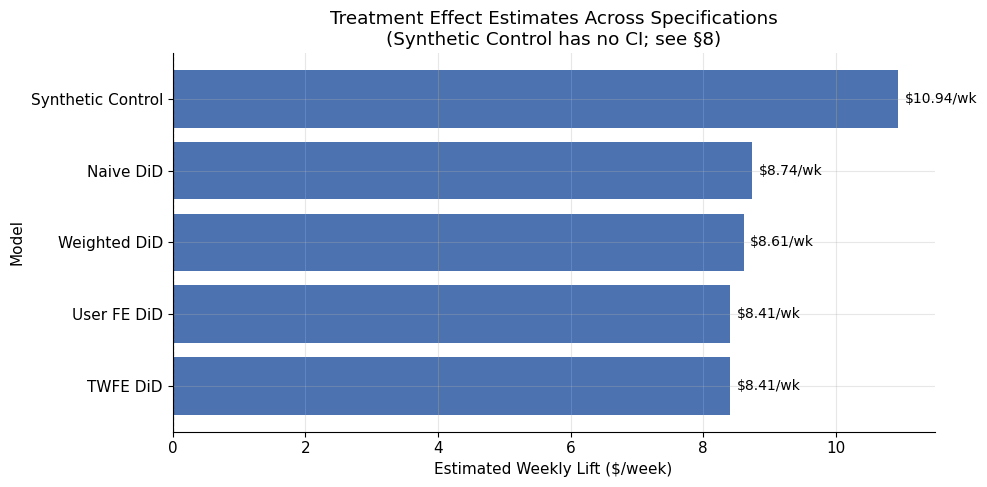

In [15]:
results_table = pd.DataFrame({
    "Model": ["TWFE DiD", "Synthetic Control", "User FE DiD", "Weighted DiD", "Naive DiD"],
    "Lift ($/week)": [
        round(twfe_coef, 2),
        round(sc_effect, 2),
        fe_res["coef"],
        round(weighted_coef, 2),
        did_res["coef"],
    ],
    "95% CI": [
        f"[${twfe_ci_low:.2f}, ${twfe_ci_high:.2f}]",
        "—",
        f"[${fe_res['ci_low']:.2f}, ${fe_res['ci_high']:.2f}]",
        f"[${weighted_ci_low:.2f}, ${weighted_ci_high:.2f}]",
        f"[${did_res['ci_low']:.2f}, ${did_res['ci_high']:.2f}]",
    ],
    "Notes": [
        "Two-way FE with valid unbalanced-panel residualization",
        "Cohort-level synthetic-control check; no CI",
        "Controls for time-invariant user characteristics",
        "IPW-reweighted robustness check",
        "Baseline; does not control for user heterogeneity",
    ],
})
results_table = results_table.sort_values("Lift ($/week)").reset_index(drop=True)

display(results_table)

colors = ["#DD8452" if v < 0 else "#4C72B0" for v in results_table["Lift ($/week)"]]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(results_table["Model"], results_table["Lift ($/week)"], color=colors)
for bar, val in zip(bars, results_table["Lift ($/week)"]):
    xpos = val + 0.1 if val >= 0 else val - 0.1
    ha   = "left"    if val >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f"${val:.2f}/wk", va="center", ha=ha, fontsize=10)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Treatment Effect Estimates Across Specifications\n(Synthetic Control has no CI; see §8)")
ax.set_xlabel("Estimated Weekly Lift ($/week)")
ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

Treatment effect estimates are consistently positive across the main robustness checks. DiD estimates
range from **+$8.41/week** (User FE / TWFE) to **+$8.74/week** (Naive DiD), while the synthetic-control check is higher.

The spread across specifications is modest after using the mart's true week index and valid
unbalanced-panel fixed-effect residualization.

The randomized post-period ATE (**+$28.50 per user over the post period**) remains the most credible
estimate of average causal impact. The weekly panel estimates are robustness checks and should not
be directly compared to the cumulative ATE.

## 8. Synthetic Control Robustness Check

The synthetic control constructs a weighted combination of control cohorts that best matches the
treated group's pre-treatment revenue trajectory, providing an alternative counterfactual based on pre-trend matching rather than parallel trends.

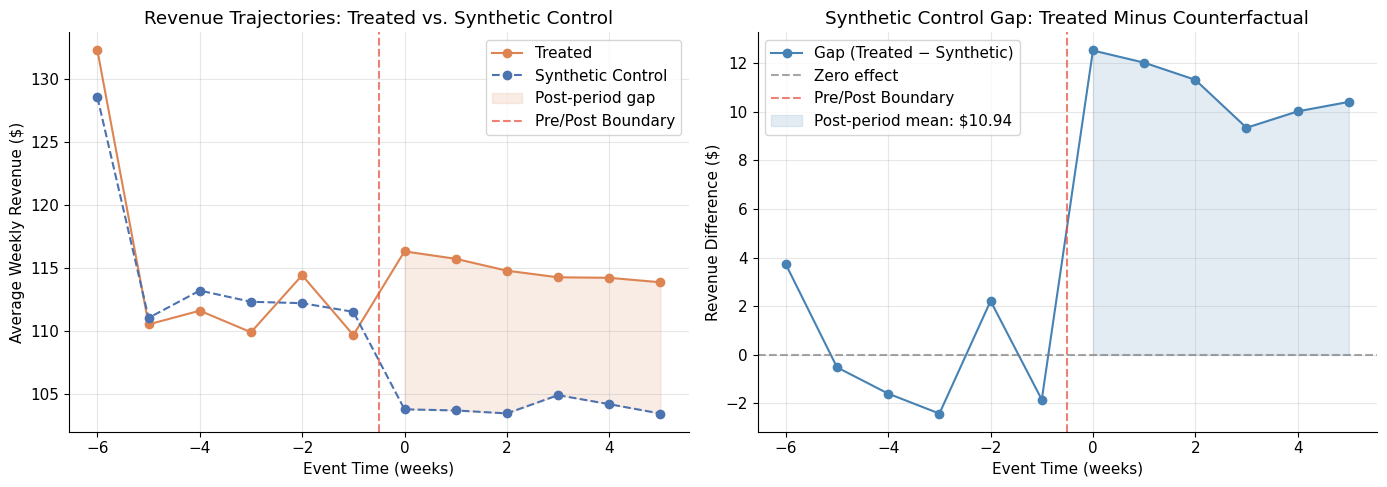

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(treated_series.index, treated_series.values,
             marker="o", color="#DD8452", label="Treated")
axes[0].plot(synthetic_series.index, synthetic_series.values,
             marker="o", linestyle="--", color="#4C72B0", label="Synthetic Control")
axes[0].fill_between(
    treated_series.index, treated_series.values, synthetic_series.values,
    where=(treated_series.index >= 0),
    alpha=0.15, color="#DD8452", label="Post-period gap",
)
axes[0].axvline(-0.5, linestyle="--", color="#e74c3c", alpha=0.7, label="Pre/Post Boundary")
axes[0].set_title("Revenue Trajectories: Treated vs. Synthetic Control")
axes[0].set_xlabel("Event Time (weeks)")
axes[0].set_ylabel("Average Weekly Revenue ($)")
axes[0].legend()

axes[1].plot(sc_effect_series.index, sc_effect_series.values,
             marker="o", color="steelblue", label="Gap (Treated − Synthetic)")
axes[1].axhline(0, linestyle="--", color="gray", alpha=0.7, label="Zero effect")
axes[1].axvline(-0.5, linestyle="--", color="#e74c3c", alpha=0.7, label="Pre/Post Boundary")
axes[1].fill_between(
    sc_effect_series.index, sc_effect_series.values, 0,
    where=(sc_effect_series.index >= 0),
    alpha=0.15, color="steelblue", label=f"Post-period mean: ${sc_effect:.2f}",
)
axes[1].set_title("Synthetic Control Gap: Treated Minus Counterfactual")
axes[1].set_xlabel("Event Time (weeks)")
axes[1].set_ylabel("Revenue Difference ($)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation

The synthetic control estimates a post-period effect of approximately **+$10.94/user-week**, with a
pre-period fit RMSE of 2.27, indicating reasonable pre-period tracking.

This is somewhat higher than the DiD estimates (~$8.41–8.74). Under randomization a simple
difference-in-means already provides an unbiased estimate, so SC functions here as supplementary
corroboration rather than a preferred identification strategy. The higher estimate likely reflects
modest donor overfit: only six pre-period weeks are available to fit the cohort weights, and with
few observations the optimizer can chase noise in the pre-period. The randomized post-period ATE
remains the headline causal result.


## 9. Business Impact

In [17]:
discount_rate = 0.10

# Business-impact calculation based on the randomized cumulative post-period ATE.
# This is a simplified revenue-cost view, not a margin model.
cumulative_lift = ate_lift
cumulative_discount_cost = treat.mean() * discount_rate
net_impact_cumulative = cumulative_lift - cumulative_discount_cost

num_treated = len(treat)
total_campaign_impact = net_impact_cumulative * num_treated

pd.DataFrame({
    "Metric": [
        "Cumulative ATE Lift per User",
        "Estimated Discount Cost per User (10% of treated post revenue)",
        "Net Impact per User (cumulative post-period)",
        "Total Cumulative Campaign Impact",
    ],
    "Value": [
        f"${cumulative_lift:+.2f}",
        f"-${cumulative_discount_cost:.2f}",
        f"${net_impact_cumulative:+.2f}",
        f"${total_campaign_impact:,.0f}",
    ],
})


,Metric,Value
0,Cumulative ATE Lift per User,$+28.50
1,Estimated Discount Cost per User (10% of treat...,-$37.79
2,Net Impact per User (cumulative post-period),$-9.29
3,Total Cumulative Campaign Impact,"$-255,370"


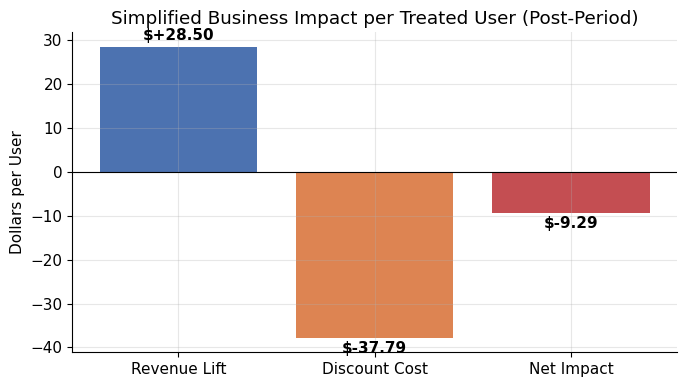

In [18]:
impact_parts = pd.DataFrame({
    "Metric": ["Revenue Lift", "Discount Cost", "Net Impact"],
    "Value": [cumulative_lift, -cumulative_discount_cost, net_impact_cumulative],
})

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4C72B0", "#DD8452", "#55A868" if net_impact_cumulative >= 0 else "#C44E52"]
bars = ax.bar(impact_parts["Metric"], impact_parts["Value"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, impact_parts["Value"]):
    va = "bottom" if val >= 0 else "top"
    offset = 0.8 if val >= 0 else -0.8
    ax.text(bar.get_x() + bar.get_width() / 2, val + offset,
            f"${val:+.2f}", ha="center", va=va, fontsize=11, fontweight="bold")
ax.set_title("Simplified Business Impact per Treated User (Post-Period)")
ax.set_ylabel("Dollars per User")
plt.tight_layout()
plt.show()

The cumulative ATE lift (**+$28.50/user**) does not cover the simplified estimated discount cost
(~$37.79/user), yielding a net impact of approximately **-$9.29 per user** over the post period.
A blanket 10% discount is not profitable under this simplified short-term revenue-cost view.

**Caveats:** Revenue is simulated. A real deployment requires validation against observed transaction
data, margin impact, cannibalization effects, inventory costs, and downstream retention outcomes.

**Strategic context:** A short-term loss may be acceptable if the promotion drives trial, customer
acquisition, repeat purchase, or inventory clearance. The profitability threshold depends on the
discount rate, targeting strategy, and lifetime value uplift.


## 10. Heterogeneous Treatment Effects

Estimate treatment lift by baseline spend quartile to evaluate whether the promotion's impact
varies systematically across user segments.

In [19]:
post_df = pd.read_sql("select * from analysis.post_user_summary", conn)

pre_df = pd.read_sql("""
    select user_id, treatment_flag, sum(revenue_sim) as pre_revenue
    from marts.mart_user_week_experiment_sim
    where high_ltv_flag = 1 and pre_post_flag = 'pre'
    group by 1, 2
""", conn)

for d in (post_df, pre_df):
    d["user_id"]        = d["user_id"].astype(int)
    d["treatment_flag"] = d["treatment_flag"].astype(int)

hte_df = post_df.merge(pre_df, on=["user_id", "treatment_flag"], how="inner")
hte_df["baseline_quartile"] = pd.qcut(
    hte_df["pre_revenue"], 4, labels=["Q1 Low", "Q2", "Q3", "Q4 High"]
)

hte_summary = (
    hte_df.groupby(["baseline_quartile", "treatment_flag"])["post_revenue"]
    .mean().unstack().reset_index()
    .rename(columns={0: "control_mean", 1: "treatment_mean"})
)
hte_summary["lift"]     = hte_summary["treatment_mean"] - hte_summary["control_mean"]
hte_summary["pct_lift"] = hte_summary["lift"] / hte_summary["control_mean"] * 100
hte_summary.round(2)

treatment_flag,baseline_quartile,control_mean,treatment_mean,lift,pct_lift
0,Q1 Low,224.66,243.74,19.08,8.49
1,Q2,269.44,289.65,20.21,7.50
2,Q3,340.26,371.22,30.96,9.10
3,Q4 High,561.64,608.48,46.84,8.34


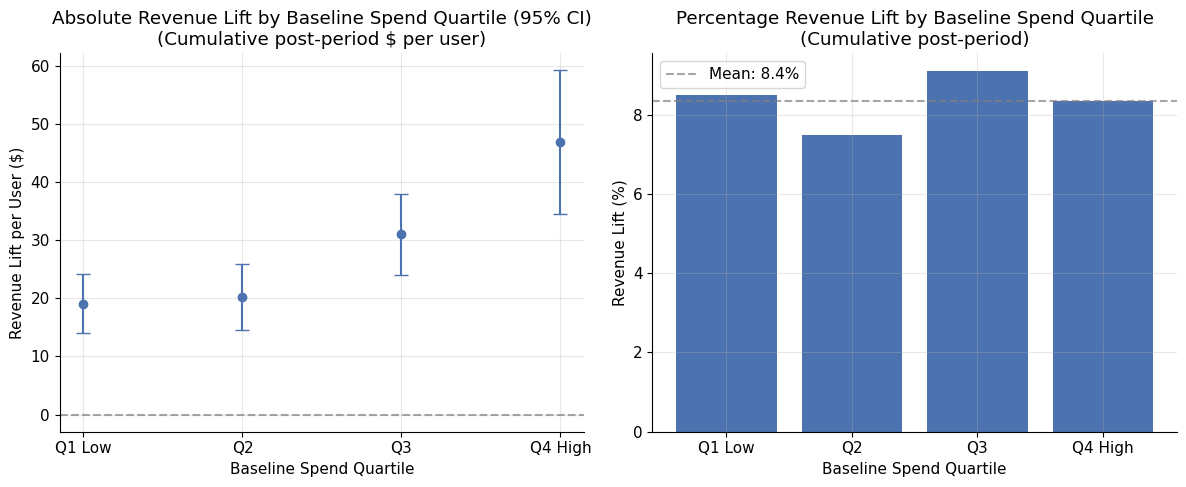

In [20]:
hte_ci = (
    hte_df.groupby(["baseline_quartile", "treatment_flag"])["post_revenue"]
    .agg(["mean", "std", "count"]).reset_index()
)
hte_ci["se"] = hte_ci["std"] / np.sqrt(hte_ci["count"])

ctrl_ci  = hte_ci[hte_ci["treatment_flag"] == 0]
treat_ci = hte_ci[hte_ci["treatment_flag"] == 1]

lift_df = ctrl_ci[["baseline_quartile", "mean", "se"]].merge(
    treat_ci[["baseline_quartile", "mean", "se"]],
    on="baseline_quartile", suffixes=("_control", "_treat"),
)
lift_df["lift"]    = lift_df["mean_treat"] - lift_df["mean_control"]
lift_df["se_lift"] = np.sqrt(lift_df["se_control"] ** 2 + lift_df["se_treat"] ** 2)
lift_df["ci_low"]  = lift_df["lift"] - 1.96 * lift_df["se_lift"]
lift_df["ci_high"] = lift_df["lift"] + 1.96 * lift_df["se_lift"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].errorbar(
    lift_df["baseline_quartile"], lift_df["lift"],
    yerr=1.96 * lift_df["se_lift"],
    fmt="o", capsize=5, color="#4C72B0",
)
axes[0].axhline(0, linestyle="--", color="gray", alpha=0.7)
axes[0].set_title("Absolute Revenue Lift by Baseline Spend Quartile (95% CI)\n(Cumulative post-period $ per user)")
axes[0].set_xlabel("Baseline Spend Quartile")
axes[0].set_ylabel("Revenue Lift per User ($)")

axes[1].bar(hte_summary["baseline_quartile"], hte_summary["pct_lift"], color="#4C72B0")
axes[1].axhline(hte_summary["pct_lift"].mean(), linestyle="--", color="gray", alpha=0.7,
                label=f"Mean: {hte_summary['pct_lift'].mean():.1f}%")
axes[1].set_title("Percentage Revenue Lift by Baseline Spend Quartile\n(Cumulative post-period)")
axes[1].set_xlabel("Baseline Spend Quartile")
axes[1].set_ylabel("Revenue Lift (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
q4_lift = hte_summary.loc[hte_summary["baseline_quartile"] == "Q4 High", "lift"].values[0]
q1_lift = hte_summary.loc[hte_summary["baseline_quartile"] == "Q1 Low",  "lift"].values[0]
q4_pct  = hte_summary.loc[hte_summary["baseline_quartile"] == "Q4 High", "pct_lift"].values[0]
q1_pct  = hte_summary.loc[hte_summary["baseline_quartile"] == "Q1 Low",  "pct_lift"].values[0]

display(Markdown(f"""
Treatment lift is positive across all four quartiles. Higher-spend users generate larger **absolute** dollar gains (${q4_lift:.2f} for Q4 High vs. ${q1_lift:.2f} for Q1 Low).

**Percentage lift** is broadly similar across segments ({hte_summary["pct_lift"].min():.1f}–{hte_summary["pct_lift"].max():.1f}%), indicating that higher baseline
revenue — not stronger causal responsiveness — drives the dollar gap. Simple baseline-spend targeting
within the high-LTV population would not meaningfully improve the promotion's efficiency.
"""))


Treatment lift is positive across all four quartiles. Higher-spend users generate larger **absolute** dollar gains ($46.84 for Q4 High vs. $19.08 for Q1 Low).

**Percentage lift** is broadly similar across segments (7.5–9.1%), indicating that higher baseline
revenue — not stronger causal responsiveness — drives the dollar gap. Simple baseline-spend targeting
within the high-LTV population would not meaningfully improve the promotion's efficiency.


## 11. Causal Forest

We complement the quartile analysis with a causal forest (`CausalForestDML`), which estimates
individual-level treatment effects using pre-period features.

**Important context:** the simulation applies a constant 8% revenue multiplier, so true percentage
responsiveness is homogeneous across users. Any variation in predicted dollar lift therefore reflects
baseline spend differences, not differential causal responsiveness. These estimates are exploratory
model-based predictions; a follow-up experiment is required before using them for production targeting.


In [22]:
cf_df = panel_df.copy()
cf_df["pre_post_flag"] = cf_df["pre_post_flag"].astype(str).str.strip().str.lower()

pre_user = (
    cf_df[cf_df["pre_post_flag"] == "pre"]
    .groupby("user_id")
    .agg(
        baseline_revenue=("revenue_sim", "mean"),
        pre_rev_std=("revenue_sim", "std"),
        pre_weeks=("revenue_sim", "count"),
        treatment_flag=("treatment_flag", "max"),
    )
    .reset_index()
)
pre_user["pre_rev_std"] = pre_user["pre_rev_std"].fillna(0)

post_user = (
    cf_df[cf_df["pre_post_flag"] == "post"]
    .groupby("user_id")
    .agg(post_revenue=("revenue_sim", "mean"))
    .reset_index()
)

user_cf = pre_user.merge(post_user, on="user_id", how="inner").dropna().copy()

Y = user_cf["post_revenue"].to_numpy()
T = user_cf["treatment_flag"].to_numpy()
X = user_cf[["baseline_revenue", "pre_rev_std", "pre_weeks"]].to_numpy()

cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, min_samples_leaf=10, random_state=42),
    model_t=RandomForestRegressor(n_estimators=100, min_samples_leaf=10, random_state=42),
    n_estimators=200, min_samples_leaf=10, random_state=42,
)
cf.fit(Y, T, X=X)
user_cf["te_pred"] = cf.effect(X)

user_cf["te_pred"].agg(["mean", "std", "min", "max"]).round(2).rename("Value").to_frame()

,Value
mean,8.40
std,5.57
min,-13.73
max,46.33


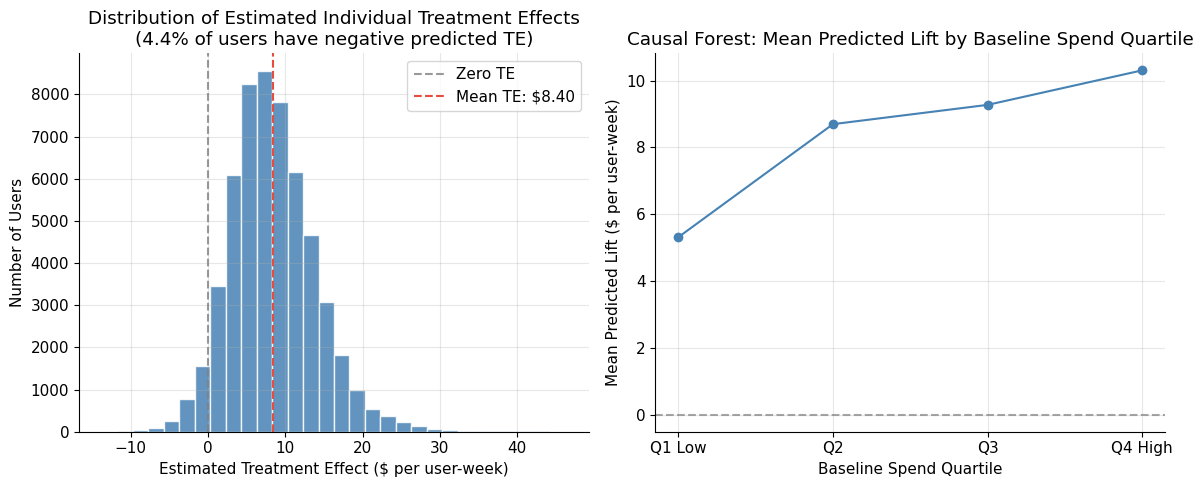

In [23]:
user_cf["baseline_quartile"] = pd.qcut(
    user_cf["baseline_revenue"], 4, labels=["Q1 Low", "Q2", "Q3", "Q4 High"]
)
cf_hte_summary = user_cf.groupby("baseline_quartile")["te_pred"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(user_cf["te_pred"], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(0, linestyle="--", color="gray", alpha=0.8, label="Zero TE")
axes[0].axvline(
    user_cf["te_pred"].mean(), linestyle="--", color="#e74c3c",
    label=f"Mean TE: ${user_cf['te_pred'].mean():.2f}",
)
pct_neg = (user_cf["te_pred"] < 0).mean() * 100
axes[0].set_title(
    f"Distribution of Estimated Individual Treatment Effects\n"
    f"({pct_neg:.1f}% of users have negative predicted TE)"
)
axes[0].set_xlabel("Estimated Treatment Effect ($ per user-week)")
axes[0].set_ylabel("Number of Users")
axes[0].legend()

axes[1].plot(cf_hte_summary["baseline_quartile"], cf_hte_summary["te_pred"],
             marker="o", color="steelblue")
axes[1].axhline(0, linestyle="--", color="gray", alpha=0.7)
axes[1].set_title("Causal Forest: Mean Predicted Lift by Baseline Spend Quartile")
axes[1].set_xlabel("Baseline Spend Quartile")
axes[1].set_ylabel("Mean Predicted Lift ($ per user-week)")

plt.tight_layout()
plt.show()

In [24]:
threshold   = user_cf["te_pred"].quantile(0.8)
top_users   = user_cf[user_cf["te_pred"] >= threshold]
other_users = user_cf[user_cf["te_pred"] < threshold]

pd.DataFrame({
    "Segment": ["Top 20% (highest predicted TE)", "Bottom 80%"],
    "Users": [len(top_users), len(other_users)],
    "Mean Predicted Lift ($ per user-week)": [
        round(top_users["te_pred"].mean(), 2),
        round(other_users["te_pred"].mean(), 2),
    ],
})

,Segment,Users,Mean Predicted Lift ($ per user-week)
0,Top 20% (highest predicted TE),11021,16.55
1,Bottom 80%,44081,6.36


In [25]:
cf_mean    = user_cf["te_pred"].mean()
cf_std     = user_cf["te_pred"].std()
cf_min     = user_cf["te_pred"].min()
cf_max     = user_cf["te_pred"].max()
top_mean   = top_users["te_pred"].mean()
other_mean = other_users["te_pred"].mean()

display(Markdown(f"""
The causal forest suggests variation in predicted lift: mean **${cf_mean:.2f}**,
SD **${cf_std:.2f}**, range [${cf_min:.2f}, +${cf_max:.2f}].

The top 20% of users by predicted lift have a mean effect of **${top_mean:.2f}**, versus **${other_mean:.2f}** for the
remaining 80%. This difference reflects higher baseline spend in that segment — consistent with the
flat ~8% percentage lift observed across quartiles — rather than stronger causal responsiveness.
Because the simulation applies a uniform multiplier, the forest recovers dollar-scale heterogeneity,
not differential ROI. These predictions require validation in a follow-up experiment before deployment.
"""))



The causal forest suggests variation in predicted lift: mean **$8.40**,
SD **$5.57**, range [$-13.73, +$46.33].

The top 20% of users by predicted lift have a mean effect of **$16.55**, versus **$6.36** for the
remaining 80%. This difference reflects higher baseline spend in that segment — consistent with the
flat ~8% percentage lift observed across quartiles — rather than stronger causal responsiveness.
Because the simulation applies a uniform multiplier, the forest recovers dollar-scale heterogeneity,
not differential ROI. These predictions require validation in a follow-up experiment before deployment.


## Business Implications

The simulated randomized experiment provides evidence of a positive revenue lift under the modeled
10% discount scenario. However, the cumulative lift does not cover the simplified estimated discount
cost, so a blanket rollout is not profitable under a short-term revenue-cost objective.

The business decision depends on strategic context:
- **Profitability objective:** Avoid blanket rollout; test lower discount levels (5-7%) or targeted rollout to high-TE users
- **Trial or acquisition objective:** Short-term loss may be acceptable if the promotion drives durable repeat purchase or category expansion
- **Inventory objective:** Discount may be justified if it clears slow-moving inventory and reduces holding costs

## Limitations & Future Work

- **Revenue is simulated** (deterministic 8% uplift on treated post-period rows); real-world results require validation against observed transaction data
- **Simplified discount model:** actual cost depends on product margins, cannibalization, inventory effects, and lifetime value
- **Short pre-period window:** event-study diagnostics do not reject pre-trends at the 5% level, but only six pre-period weeks are available
- **Causal forest targets are exploratory:** model-based HTE estimates require a validation experiment before deployment
- **Future improvements:** stratified randomization by baseline spend quartile, better pre-treatment features for HTE exploration, longer pre-treatment windows

## Business Recommendation

1. **Do not broadly deploy** the 10% discount if the objective is short-term revenue-cost efficiency under this simplified cost model
2. **Explore lower discount rates** (5-7%) to find a profitable threshold
3. **Use stratified randomization** in future experiments to ensure balance across spend segments
4. **Run a validation experiment** targeting the top predicted-TE segment from the causal forest before operationalizing ML-driven targeting
5. **Track downstream outcomes** (repeat purchase, retention, margin) to capture the full value of the promotion

## Final Takeaway

The randomized experiment provides the most credible causal estimate: **+$28.50 per user cumulative
over observed post-period transaction-weeks** (95% CI [$23.90, $33.11]). This comes from a
randomized diff-in-means on post-period revenue summed per user.

The weekly DiD panel estimates range from **+$8.41 to +$8.74/week**, with TWFE at **+$8.41/week**.
These are consistent with the ATE: ~$8.50/wk × ~3.3 observed post-weeks per user ≈ $28.50. The event
study is diagnostic, not dispositive. Because the true treatment effect is a known +8% uplift, the
ATE recovering +8.2% and the DiD recovering ~8%/wk also confirms the estimators work correctly on
this simulation.

Using the cumulative ATE for a simple business-impact calculation, the promotion produces about
**+$28.50/user** in incremental post-period revenue but costs roughly **$37.79/user** under a 10%
discount-cost assumption. That implies a short-term net impact of about **-$9.29/user**, before
margins, retention, or strategic benefits.

The key actionable insight is that **targeted discounting** may improve profitability, but model-based
targeting should be validated in a follow-up experiment before deployment.


---

# Appendix

Full regression outputs for all DiD specifications. Focus on the `interaction` (or `did`) coefficient,
its clustered standard error, and the 95% confidence interval.

### A1. Clustered Difference-in-Differences

In [26]:
display(did_cluster.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            revenue_sim   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     431.1
Date:                Wed, 27 May 2026   Prob (F-statistic):          3.31e-277
Time:                        18:12:33   Log-Likelihood:            -2.5086e+06
No. Observations:              440501   AIC:                         5.017e+06
Df Residuals:                  440497   BIC:                         5.017e+06
Df Model:                           3                                         
Covariance Type:              cluster                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            116.5163      0.317    367.547      0.000     115.895     117.138
treatment_flag    -0.2446      0.451     -0.542      0.588      -1.129       0.639
post             -10.0993      0.288    -35.066      0.000     -10.664      -9.535
interaction        8.7428      0.432     20.225      0.000       7.896       9.590
==============================================================================
Omnibus:                   401277.423   Durbin-Watson:                   1.305
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         86310109.495
Skew:                           3.759   Prob(JB):                         0.00
Kurtosis:                      71.161   Cond. No.                         6.44
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

The interaction coefficient (treatment x post) represents the incremental weekly revenue lift
without controlling for user heterogeneity or time fixed effects.

### A2. User Fixed Effects DiD

In [27]:
display(fe_cluster.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            revenue_sim   R-squared (uncentered):                   0.006
Model:                            OLS   Adj. R-squared (uncentered):              0.006
Method:                 Least Squares   F-statistic:                              1053.
Date:                Wed, 27 May 2026   Prob (F-statistic):                        0.00
Time:                        18:12:33   Log-Likelihood:                     -2.3641e+06
No. Observations:              440501   AIC:                                  4.728e+06
Df Residuals:                  440499   BIC:                                  4.728e+06
Df Model:                           2                                                  
Covariance Type:              cluster                                                  
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
post          -11.4874      0.258    -44.554      0.000     -11.993     -10.982
interaction     8.4134      0.380     22.159      0.000       7.669       9.158
==============================================================================
Omnibus:                   116766.879   Durbin-Watson:                   2.252
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1655701.770
Skew:                           0.887   Prob(JB):                         0.00
Kurtosis:                      12.331   Cond. No.                         2.62
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
"""

The interaction coefficient controls for time-invariant user heterogeneity. Its similarity to the
naive DiD estimate supports the direction of the estimated lift.

### A3. Two-Way Fixed Effects DiD

In [28]:
display(twfe_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            revenue_sim   R-squared (uncentered):                   0.001
Model:                            OLS   Adj. R-squared (uncentered):              0.001
Method:                 Least Squares   F-statistic:                              495.5
Date:                Wed, 27 May 2026   Prob (F-statistic):                   2.46e-109
Time:                        18:12:33   Log-Likelihood:                     -2.3616e+06
No. Observations:              440501   AIC:                                  4.723e+06
Df Residuals:                  440500   BIC:                                  4.723e+06
Df Model:                           1                                                  
Covariance Type:              cluster                                                  
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
did            8.4113      0.378     22.260      0.000       7.671       9.152
==============================================================================
Omnibus:                   115671.675   Durbin-Watson:                   2.252
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1685686.179
Skew:                           0.867   Prob(JB):                         0.00
Kurtosis:                      12.425   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
"""

The `did` coefficient (TWFE-residualized treatment x post indicator) remains positive after
absorbing both user and time fixed effects, supporting the overall direction of the randomized ATE.